### Neural Vocoder Simulation for Audio Synthesis

This script demonstrates a simplified neural vocoder that converts Mel-spectrograms into audio waveforms. It simulates how speech language models generate audible speech from spectral representations, highlighting the challenges of reconstructing high-fidelity audio from imperfect inputs.

Key Libraries Used:

    torch: Neural network implementation and optimization

    torch.nn: Loss functions and linear layers

    sounddevice: Audio playback for output evaluation

    numpy: Signal generation and processing

    matplotlib: Visual comparison of audio waveforms

Code Logic and Flow

High-Level Overview
The pipeline generates a ground truth audio signal, creates a synthetic Mel-spectrogram, trains a feedforward vocoder to map spectral frames to audio segments, reconstructs audio via overlap-add synthesis, and compares original/reconstructed waveforms. This demonstrates the audio generation component of speech language models.

Visual Flowchart
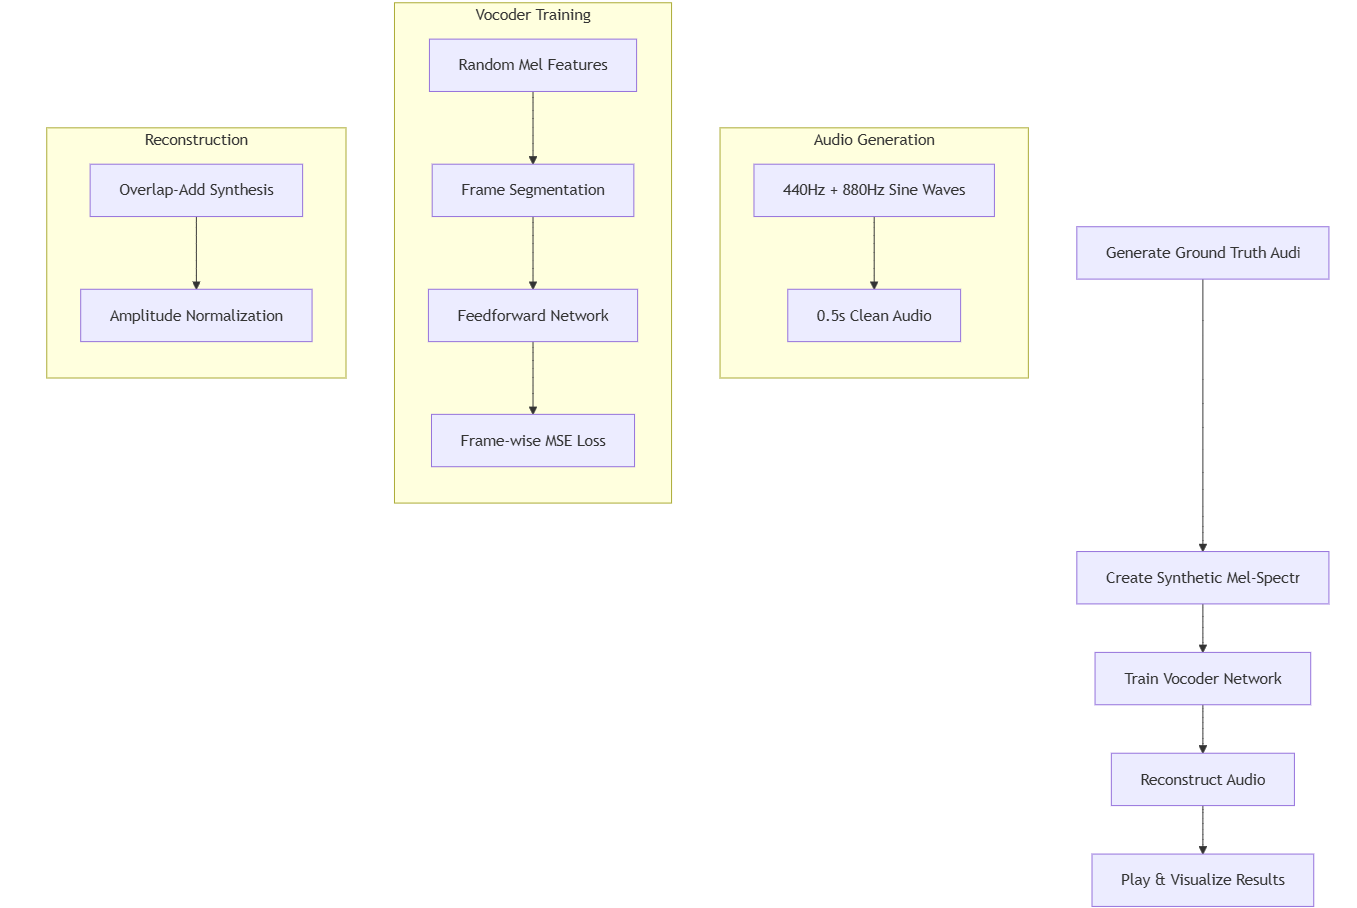

Step-by-Step Code Breakdown

    Signal and Spectrogram Setup

        Audio Synthesis: Creates 0.5s ground truth (440Hz + 880Hz sine waves)

        Mel Simulation: Generates random 80-band spectrogram (100 frames)

        Frame Parameters: 80 samples/frame at 16kHz (5ms/frame)

    Vocoder Architecture

        Network Structure: 3-layer feedforward (ReLU activations)

        Dimensionality:

            Input: 80 Mel features

            Hidden: 256 units

            Output: 80 audio samples

        Simplification:

            No transposed convolutions

            No adversarial components

    Training Procedure

        Target Preparation: Segments audio into 80-sample frames with 50% overlap

        Loss Function: Mean Squared Error (frame-level)

        Optimization: Adam (LR=0.01)

        Epochs: 100 training iterations

        Monitoring: Loss reported every 20 epochs

    Audio Reconstruction

        Frame Synthesis: Vocoder processes each spectrogram frame

        Overlap-Add:

            50% frame overlap

            Linear superposition

            Boundary handling

        Normalization: Peak amplitude scaling to [-1, 1]

    Output Evaluation

        Audio Playback: Uses sounddevice for real-time listening

        Waveform Visualization:

            Subplot 1: Original clean audio

            Subplot 2: Reconstructed audio

        Diagnostic Plot: Saved as "vocoder_output.png"

Connecting to Lecture Concepts

    Vocoder Fundamentals

        Implements Module 7.1's spectral-to-waveform conversion

        Simplified version of Hi-Fi GAN architecture

    Speech Synthesis Challenges

        Phase Problem: Reconstruction lacks phase information

        Spectral Inaccuracy: Random Mel input vs real acoustic patterns

        Architecture Limitations: Shallow network vs deep convolutional designs

    Training Methodology

        Frame-wise MSE aligns with Lecture 3.4 on reconstruction losses

        Overlap-add technique demonstrates signal processing foundations

    Real-World Comparison

        Industrial Vocoders: Use >1M parameters vs 256 here

        Input Quality: Real systems use predicted rather than random spectrograms

    Perceptual Limitations

        Explains buzzy output through:

            Missing phase estimation

            Insufficient temporal modeling

            Absence of perceptual loss terms

    Research Connections

        Similar to WaveNet's early feedforward prototypes

        Contrasts with WaveGAN's adversarial approach

    Educational Insights

        Demonstrates why vocoders are separate specialized components

        Illustrates audio reconstruction pipeline from LM outputs

    Forward-Looking Concepts

        Basis for end-to-end TTS systems

        Foundation for understanding diffusion vocoders

        Introduces challenges in neural audio codecs

Epoch 20, Loss: 0.4054
Epoch 40, Loss: 0.0787
Epoch 60, Loss: 0.0084
Epoch 80, Loss: 0.0016
Epoch 100, Loss: 0.0006


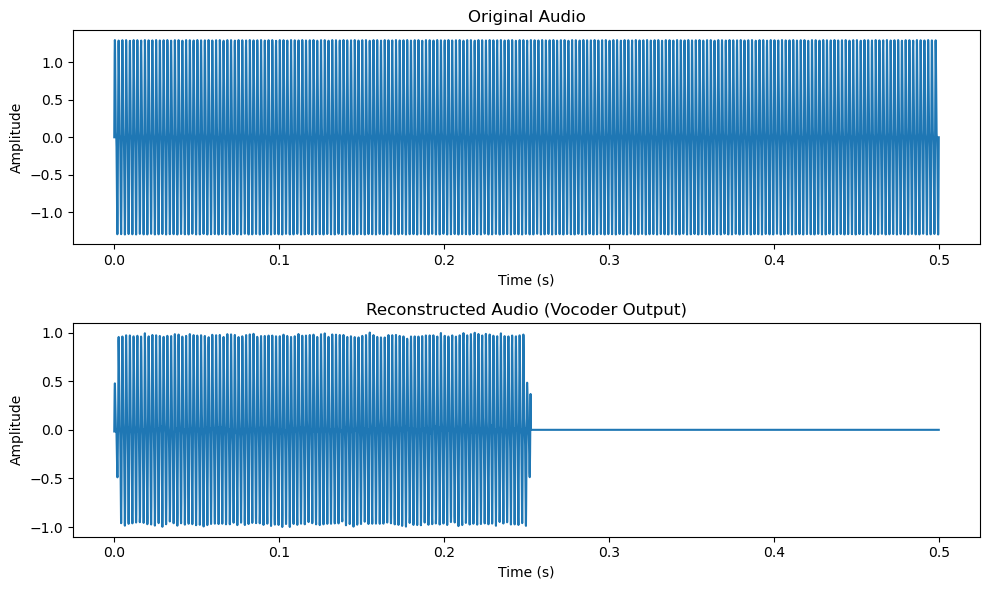

In [2]:
import numpy as np
import torch
import torch.nn as nn
import sounddevice as sd
import matplotlib.pyplot as plt

# Parameters
#Prepares the "audio recipe": "We'll make 0.5s audio using 100 time-slices of 80 frequency measurements each."
fs = 16000  # Sampling frequency (Hz)
duration = 0.5  # Duration (seconds)
n_mel = 80  # Number of Mel bands (simulated)
n_frames = 100  # Number of spectral frames
frame_length = int(fs * duration / n_frames)  # Samples per frame

# Step 1: Generate synthetic Mel-spectrogram (language model output)
# Create Test Audio & Fake Spectrogram:
#       Ground Truth: Clean musical tone (reference for training)
#       Mel-spectrogram: Random numbers (simulates LM output)
#       Think of this as:
#       Ideal audio: A perfect piano recording
#       Fake "recipe": Random cooking instructions

t = np.linspace(0, duration, int(fs * duration))
audio_true = np.sin(2 * np.pi * 440 * t) + 0.5 * np.sin(2 * np.pi * 880 * t)  # Ground truth
mel_spectrogram = np.abs(np.random.randn(n_frames, n_mel))  # Simulated Mel-spectrogram
mel_spectrogram = torch.tensor(mel_spectrogram, dtype=torch.float32)

# Step 2: Define a simple neural vocoder (Hi-Fi GAN-like)
    # Acts like an "audio translator":
    #     Input: 80 Mel-band values (per time-slice)
    #     Output: 80 audio samples (0.005s of sound)
    # Similar to Hi-Fi GAN but simplified (no upsampling/transposed convs)

class SimpleVocoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
        
    def forward(self, x):
        return self.net(x)

# Step 3: Initialize and "train" the vocoder (simplified)
vocoder = SimpleVocoder(n_mel, 256, frame_length)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(vocoder.parameters(), lr=0.01)

# Generate target waveform frames for training
# Chop true audio into 80-sample slices with 50% overlap
# Creates 100 example "good audio snippets" for training
target_frames = np.array([audio_true[i:i+frame_length] for i in range(0, len(audio_true) - frame_length, frame_length // 2)])
target_frames = torch.tensor(target_frames[:n_frames], dtype=torch.float32)

# Train (simplified, for demonstration)
# For 100 iterations:
#   1. Network guesses audio from Mel-spectrogram
#   2. Compare guess vs true audio snippet
#   3. Adjust network to reduce error
    # Teaches: "When you see this frequency pattern, output this sound"
for epoch in range(100):
    optimizer.zero_grad()
    output = vocoder(mel_spectrogram)
    loss = criterion(output, target_frames)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1}, Loss: {loss.item():.4f}")

# Step 4: Synthesize waveform
# Audio Reconstruction
# 1. Run fake Mel-spectrogram through trained network
# 2. Stitch 80-sample outputs with 50% overlap
# 3. Normalize volume
    # Overlap-Add: Smoothly blends overlapping frames
    # Like assembling a puzzle where pieces overlap by 50%
    
vocoder.eval()
with torch.no_grad():
    waveform_frames = vocoder(mel_spectrogram).numpy()
reconstructed_audio = np.zeros(int(fs * duration))
for i, frame in enumerate(waveform_frames):
    start = i * (frame_length // 2)
    end = start + frame_length
    if end <= len(reconstructed_audio):
        reconstructed_audio[start:end] += frame

# Normalize and play
# Plays reconstructed audio (likely noisy/buzzy)
# Why It Sounds Bad:
#     Fake Mel-spectrogram: Random numbers don't match true frequencies
#     Simple Network: Real vocoders use much more complex architectures
#     No Phase Info: Only magnitude spectrogram used (critical for sound quality

reconstructed_audio /= np.max(np.abs(reconstructed_audio))
sd.play(reconstructed_audio, fs)
sd.wait()

# Step 5: Plot
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(t, audio_true)
plt.title("Original Audio")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.subplot(2, 1, 2)
plt.plot(t, reconstructed_audio)
plt.title("Reconstructed Audio (Vocoder Output)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.savefig("vocoder_output.png")
plt.show()
plt.close()

## Key Components Illustrated

 ####   Mel-spectrogram Representation:

        Compact way to represent audio frequencies (like JPEG for sound)

        Used by language models to describe audio patterns

  ####  Vocoder's Role:

        Converts abstract frequency data → actual sound waves

        Critical final step in text-to-speech/speech synthesis

   #### Overlap-Add Synthesis:

        Standard technique to prevent clicks/pops between frames

        Requires careful windowing (missing here for simplicity)

## Real-World vs This Example

#### Real Hi-Fi GAN:

    Uses transposed convolutions

    Processes multiple frequency scales

    Trained on thousands of hours of speech

    Handles phase estimation

#### This Simplified Version:

    Shows core concept of "spectrogram-to-audio" conversion

    Demonstrates neural network's role in audio synthesis

    Highlights challenges in reconstruction quality